In [1]:
import os
import random
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

from pathlib import Path

DATA_DIR = Path("../data")
AO_IMGS_DIR = DATA_DIR / "ao_imgs"
AO_SEGS_DIR = DATA_DIR / "ao_segs"

img_files = sorted(AO_IMGS_DIR.glob("*.nii.gz"))
seg_files = sorted(AO_SEGS_DIR.glob("*.nii.gz"))

print(f"Found {len(img_files)} images and {len(seg_files)} segmentations")

Found 744 images and 744 segmentations


## Select Random Samples

In [2]:
NUM_SAMPLES = 4
random.seed(42)
sample_indices = random.sample(range(len(img_files)), NUM_SAMPLES)

sample_imgs = [img_files[i] for i in sample_indices]
sample_segs = [seg_files[i] for i in sample_indices]

print("Selected sample indices:", sample_indices)

Selected sample indices: [654, 114, 25, 281]


## Visualize 3D Slices

Image: AORTA_6936_0000.nii.gz
Shape: (60, 180, 240), Seg shape: (60, 180, 240)


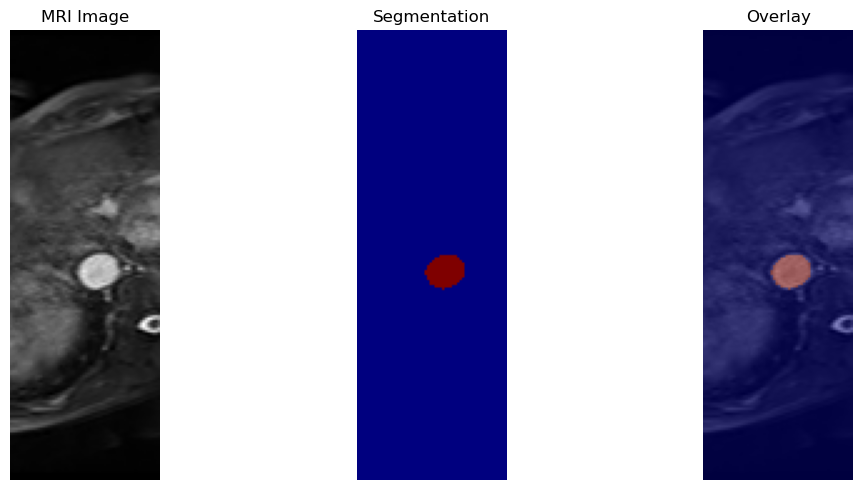

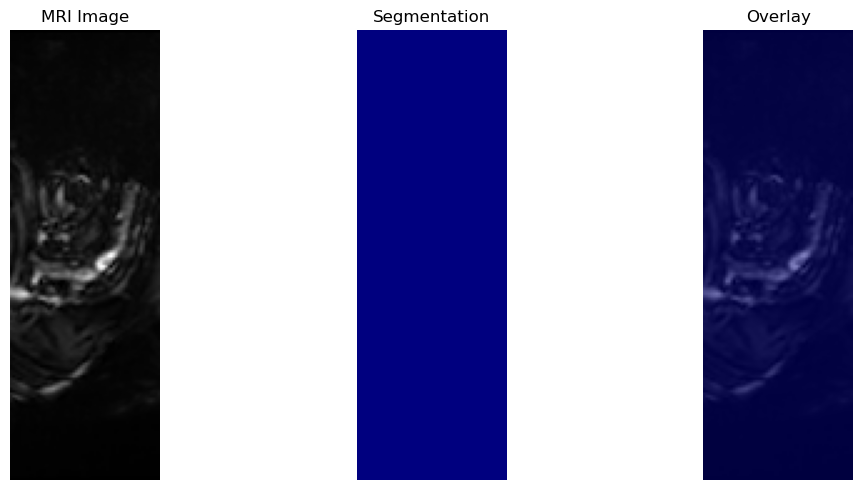

--------------------------------------------------------------------------------
Image: AORTA_27624_0000.nii.gz
Shape: (180, 240, 60), Seg shape: (180, 240, 60)


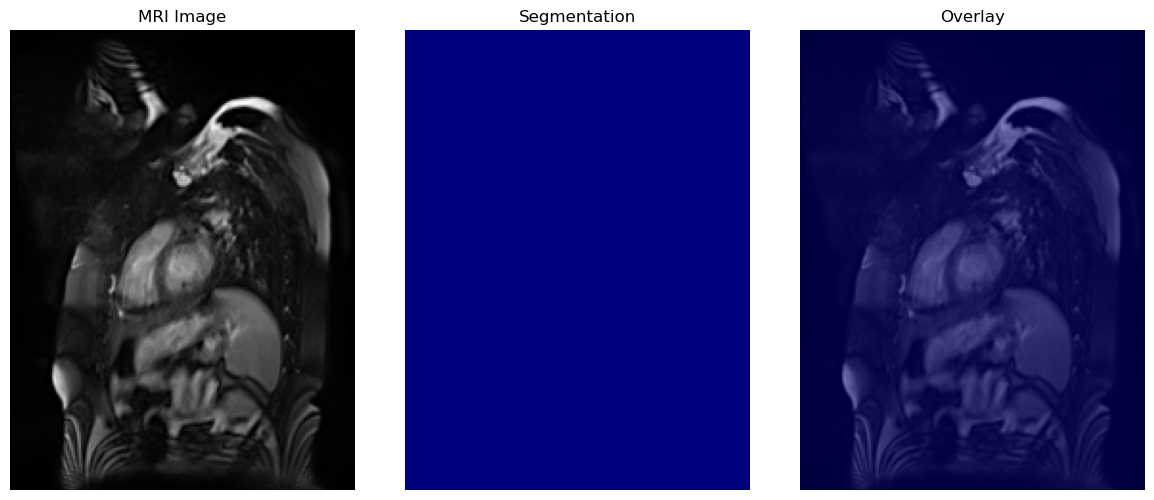

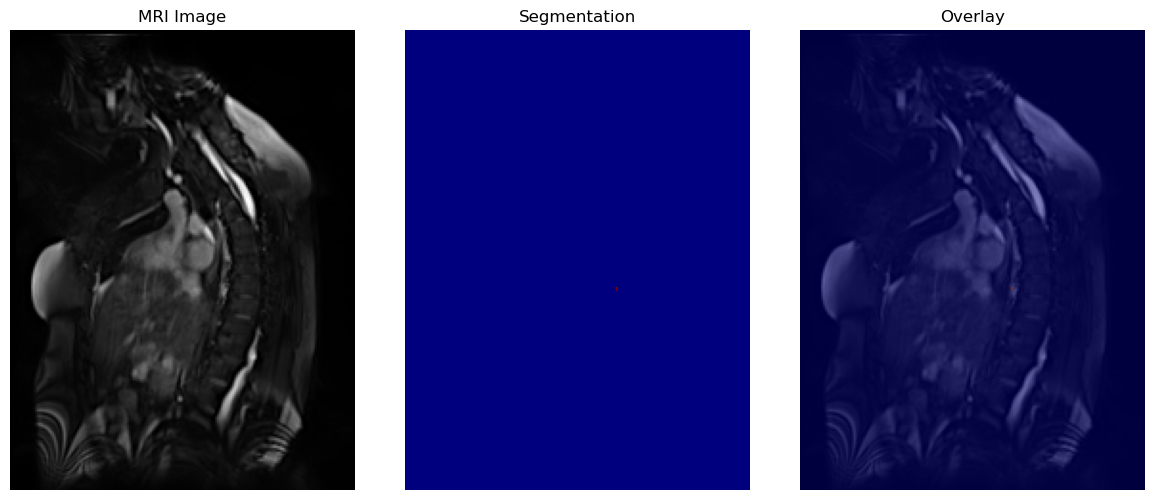

--------------------------------------------------------------------------------
Image: AORTA_108080_0000.nii.gz
Shape: (56, 180, 240), Seg shape: (56, 180, 240)


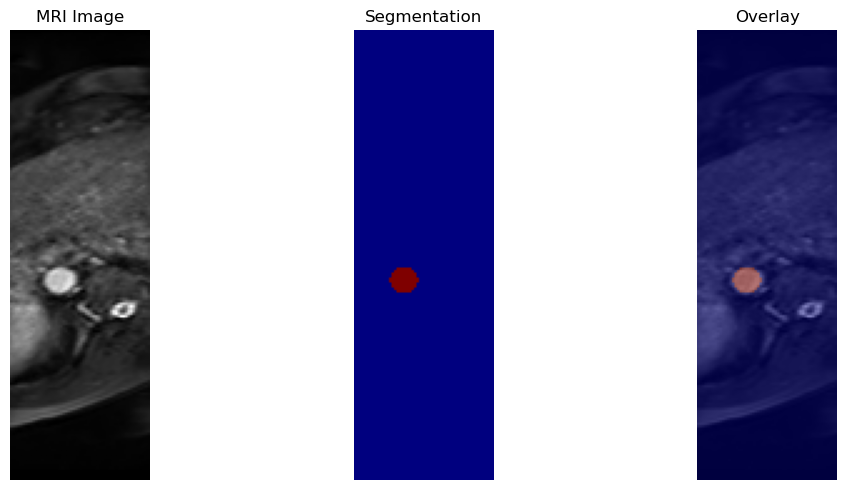

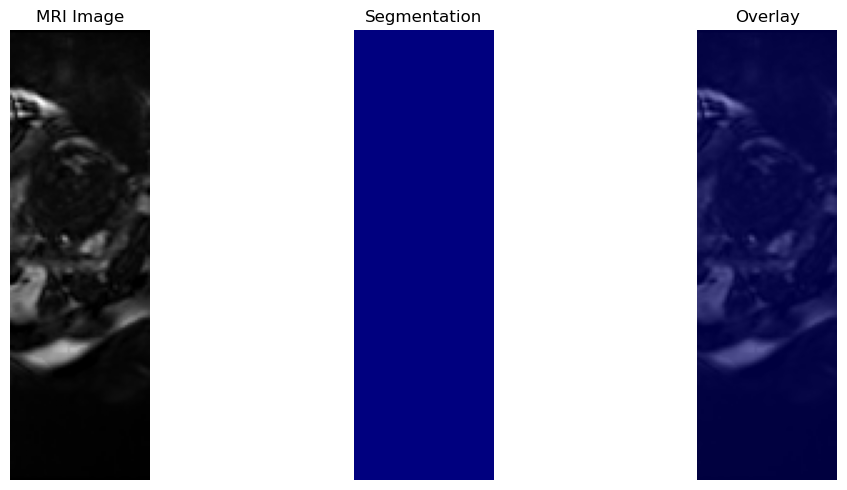

--------------------------------------------------------------------------------
Image: AORTA_30134_0000.nii.gz
Shape: (156, 240, 60), Seg shape: (156, 240, 60)


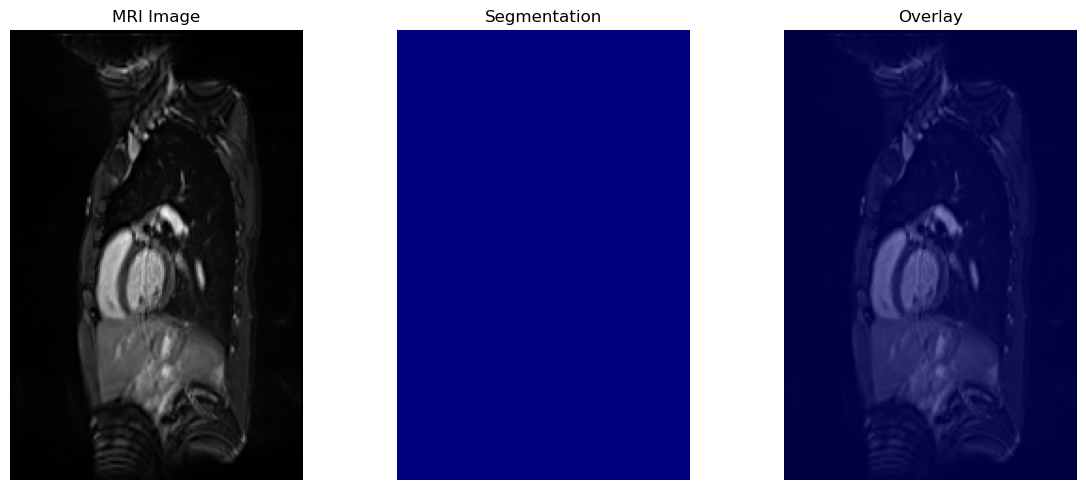

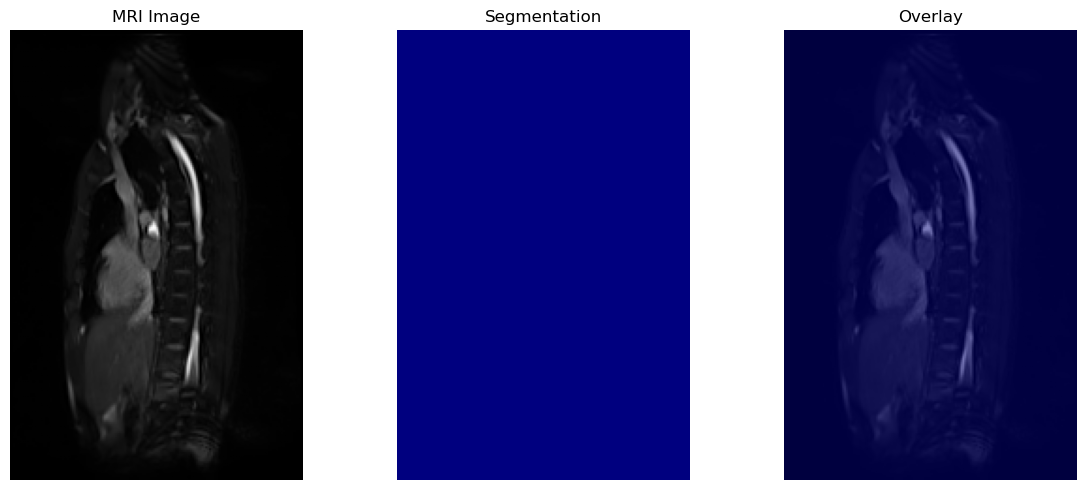

--------------------------------------------------------------------------------


In [3]:
def load_nifti(filepath):
    img = nib.load(str(filepath))
    return img.get_fdata(), img.affine, img.header


def visualize_slice(img_data, seg_data, slice_idx, plane="axial", alpha=0.5):
    if plane == "axial":
        img_slice = img_data[:, :, slice_idx]
        seg_slice = seg_data[:, :, slice_idx]
    elif plane == "sagittal":
        img_slice = img_data[slice_idx, :, :]
        seg_slice = seg_data[slice_idx, :, :]
    elif plane == "coronal":
        img_slice = img_data[:, slice_idx, :]
        seg_slice = seg_data[:, slice_idx, :]

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img_slice.T, cmap="gray", origin="lower")
    plt.title("MRI Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(seg_slice.T, cmap="jet", origin="lower")
    plt.title("Segmentation")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(img_slice.T, cmap="gray", origin="lower")
    plt.imshow(seg_slice.T, cmap="jet", alpha=alpha, origin="lower")
    plt.title("Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


def visualize_sample(img_path, seg_path, num_slices=3, plane="axial"):
    img_data, _, _ = load_nifti(img_path)
    seg_data, _, _ = load_nifti(seg_path)

    print(f"Image: {img_path.name}")
    print(f"Shape: {img_data.shape}, Seg shape: {seg_data.shape}")

    if plane == "axial":
        max_slice = img_data.shape[2]
    elif plane == "sagittal":
        max_slice = img_data.shape[0]
    elif plane == "coronal":
        max_slice = img_data.shape[1]

    slice_indices = np.linspace(max_slice // 4, 3 * max_slice // 4, num_slices, dtype=int)
    
    for idx in slice_indices:
        visualize_slice(img_data, seg_data, idx, plane)


for img_path, seg_path in zip(sample_imgs, sample_segs):
    visualize_sample(img_path, seg_path, num_slices=2, plane="axial")
    print("-" * 80)


## Visualize 3D Volume (Maximum Intensity Projection)

Image: AORTA_6936_0000.nii.gz


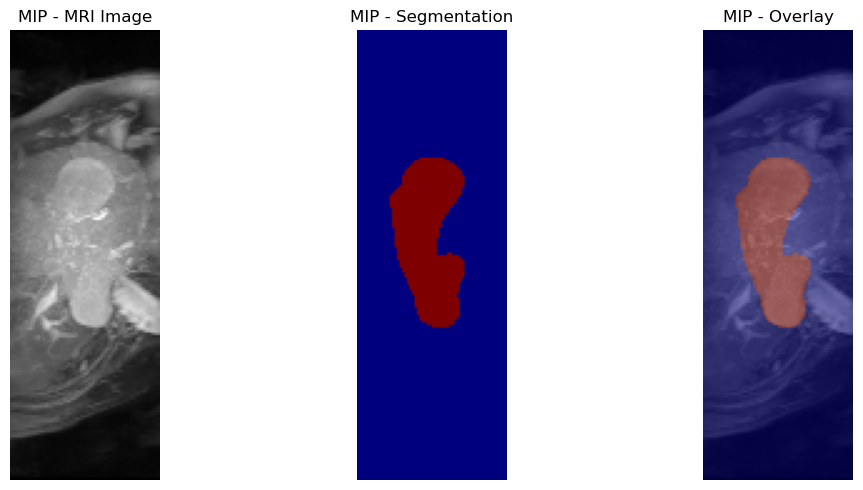

--------------------------------------------------------------------------------
Image: AORTA_27624_0000.nii.gz


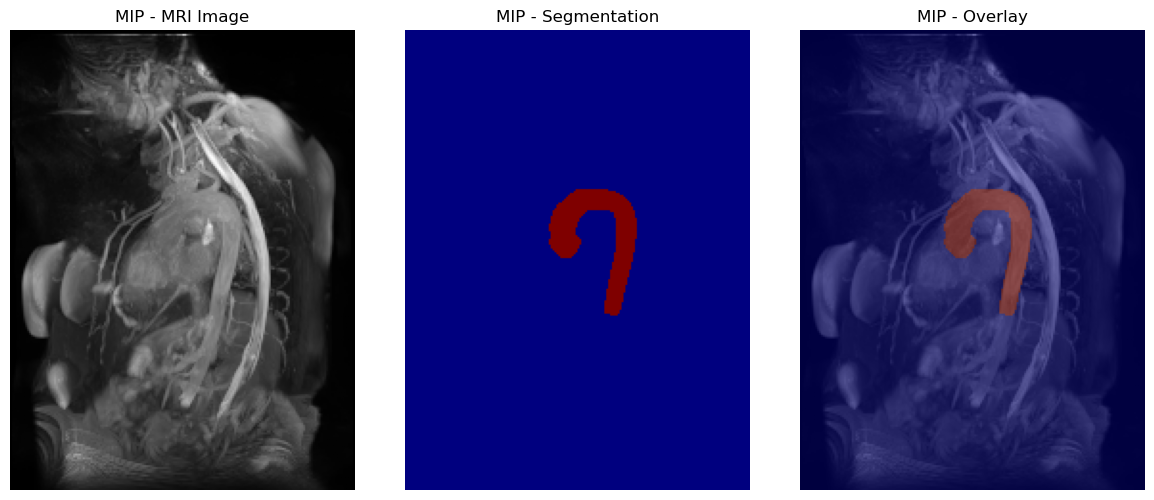

--------------------------------------------------------------------------------
Image: AORTA_108080_0000.nii.gz


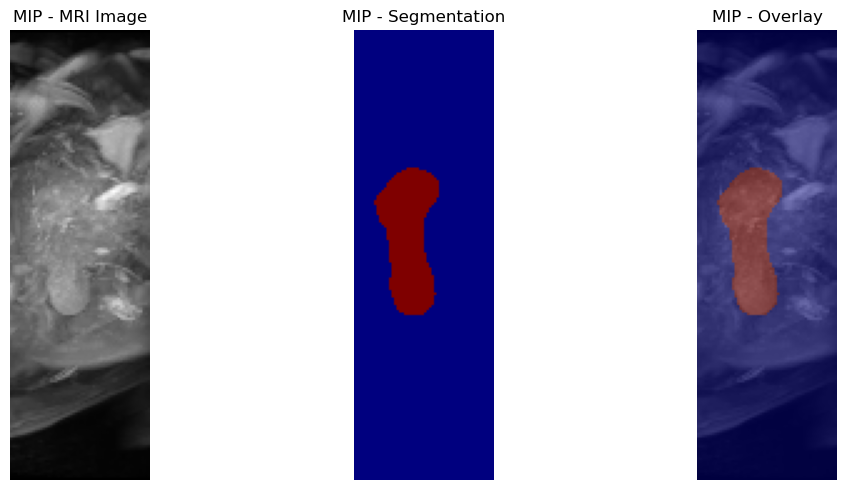

--------------------------------------------------------------------------------
Image: AORTA_30134_0000.nii.gz


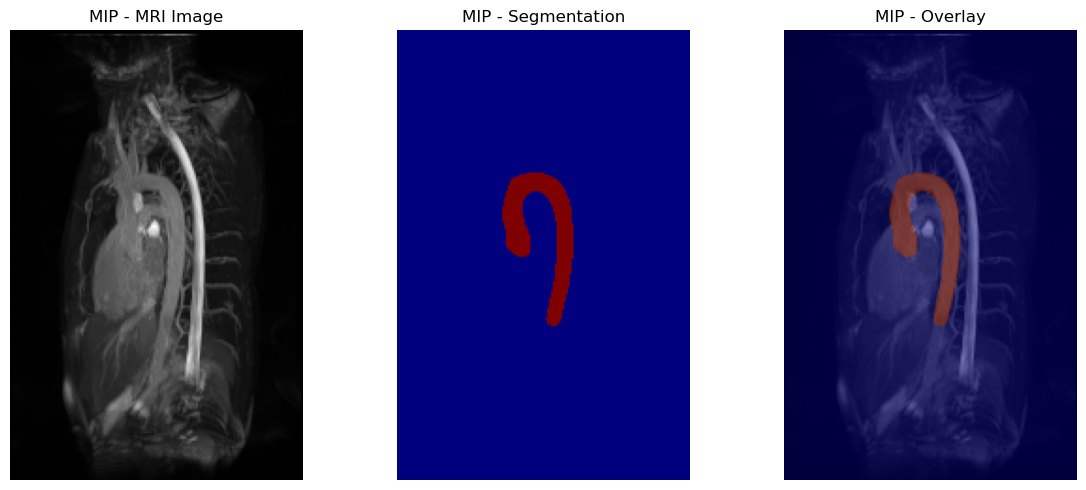

--------------------------------------------------------------------------------


In [4]:
def visualize_mip(img_data, seg_data):
    mip_img = np.max(img_data, axis=2)
    mip_seg = np.max(seg_data, axis=2)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(mip_img.T, cmap="gray", origin="lower")
    plt.title("MIP - MRI Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mip_seg.T, cmap="jet", origin="lower")
    plt.title("MIP - Segmentation")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(mip_img.T, cmap="gray", origin="lower")
    plt.imshow(mip_seg.T, cmap="jet", alpha=0.5, origin="lower")
    plt.title("MIP - Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


for img_path, seg_path in zip(sample_imgs, sample_segs):
    img_data, _, _ = load_nifti(img_path)
    seg_data, _, _ = load_nifti(seg_path)
    print(f"Image: {img_path.name}")
    visualize_mip(img_data, seg_data)
    print("-" * 80)
